# Planetary-dominated eddies: background tilt direction

## Corrected signed-PV hypothesis

This uses the mathematical gradient of **signed** PV. In the Southern Hemisphere, $\nabla f/h$ points northward (equatorward). AEs are predicted to **align** with signed $\nabla PV$; CEs are predicted to **oppose** it. Both may retain a similar westward component, so this is an angular tendency rather than an exact bearing.

Planetary-dominated observations define the background bearing used later. Cached outputs were cleared because the corrected gradient bearings differ by approximately $180^\circ$.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

## 1. Load data and define the planetary-dominated population

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 5.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = tilt.add_region_labels(df, grid)
df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR,
    min_open_ocean_depth_m=MIN_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

# Compass bearing: 0° = north and 90° = east.
planetary['tilt_x_km'] = planetary.TiltDis * np.sin(np.deg2rad(planetary.TiltDir))
planetary['tilt_y_km'] = planetary.TiltDis * np.cos(np.deg2rad(planetary.TiltDir))

display(planetary.groupby('Cyc').agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_depth_m=('h', 'median'), median_tilt_km=('TiltDis', 'median')
).round(2))

,observations,eddies,median_depth_m,median_tilt_km
Cyc,,,,
AE,5184,364,4837.76,16.64
CE,1069,146,4853.47,15.36


## 2. Spatial and directional context

The maps check that the selected population is genuinely offshore. The polar distributions show bearings, while the component plots directly test the vector hypothesis.

AE mean tilt dir 18,    tilt dis 21 km
CE mean tilt dir 154,    tilt dis 20 km
Planetary ≥ 2× and depth ≥ 3,000 m


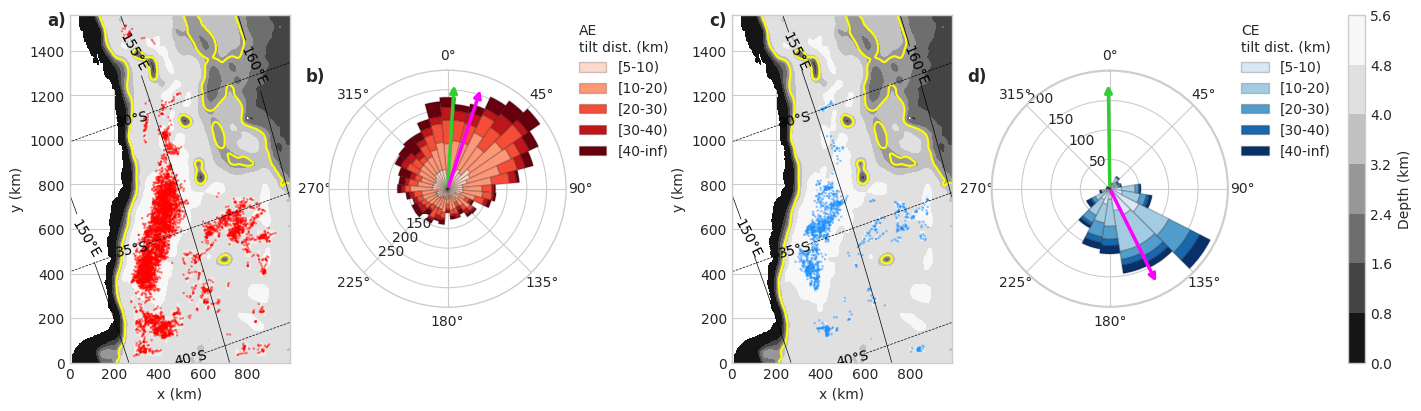

In [3]:
fig = plt.figure(figsize=(14, 4), constrained_layout=True)

axs = [
    fig.add_subplot(1, 4, 1),
    fig.add_subplot(1, 4, 2, projection='polar'),
    fig.add_subplot(1, 4, 3),
    fig.add_subplot(1, 4, 4, projection='polar')
]

mag_bins = [5, 10, 20, 30, 40, np.inf]

for i, cyc in enumerate(['AE', 'CE']):
    ax, axw = axs[2*i], axs[2*i+1]
    df = planetary[planetary.Cyc == cyc].copy()
    cmap = 'Reds' if cyc == 'AE' else 'Blues'
    col = 'r' if cyc == 'AE' else 'dodgerblue'
    colors = getattr(plt.cm, cmap)(np.linspace(.15, 1, len(mag_bins)-1))

    # Map
    bath = ax.contourf(
        grid.X_grid, grid.Y_grid,
        np.where(grid.mask_rho, grid.h/1e3, np.nan),
        cmap='Greys_r'
    )

    ax.hist2d(df.xc, df.yc, bins=50, cmap=cmap, alpha=.6, cmin=2)
    ax.scatter(df.xc, df.yc, s=3, c=col, alpha=.5, edgecolors='none')
    ax.contour(grid.X_grid, grid.Y_grid, grid.h,
               levels=[MIN_DEPTH_m], colors='yellow')

    tilt.lat_lon_contours(ax, grid)
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_xlim(grid.X_grid.min(), grid.X_grid.max())
    ax.set_ylim(grid.Y_grid.min(), grid.Y_grid.max())

    ax.set_aspect('equal', adjustable='box')

    # Windrose
    df = df.dropna(subset=['TiltDir', 'TiltDis'])
    tilt.plot_windrose(axw, df, title='', mag_bins=mag_bins, colors=colors)#, rotate=20)

    # PV arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'PV_grad_theta'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    rmax = axw.get_ylim()[1]
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='limegreen')
    )

    # tilt arrow
    theta = np.deg2rad(
        planetary.loc[planetary.Cyc == cyc, 'TiltDir'].dropna()
    )
    theta_mean = np.arctan2(np.mean(np.sin(theta)), np.mean(np.cos(theta)))
    print(f'{cyc} mean tilt dir {np.rad2deg(theta_mean):.0f},\
    tilt dis {planetary[planetary.Cyc==cyc].TiltDis.mean():.0f} km')
    axw.annotate(
        '',
        xy=(theta_mean, 0.9*rmax),
        xytext=(theta_mean, 0),
        arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta')
    )
    
    axw.legend(
        title=f'{cyc}\ntilt dist. (km)',
        loc='upper left',
        bbox_to_anchor=(1.0, 1.25),
        frameon=False
    )

# Single bathymetry colourbar
cbar = fig.colorbar(bath, ax=axs, orientation='vertical',
                    fraction=.02, pad=.01)
cbar.set_label('Depth (km)')

for ax, label in zip(axs, ['a)', 'b)', 'c)', 'd)']):
    ax.text(-0.1, 1.01, label,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=12, fontweight='bold')

print('Planetary ≥ 2×' if MIN_DEPTH_m==0.0 else f'Planetary ≥ 2× and depth ≥ {MIN_DEPTH_m:,.0f} m')
plt.show()

## 3. Direct signed-PV preference test

If $\Delta\theta$ is the unsigned tilt-to-PV angle, the prediction is $0^\circ$ for AEs and $180^\circ$ for CEs. The polarity-aware error below is zero for either predicted response.


,observations,eddies,median_raw_mismatch,median_preference_error,mean_response_cosine
Cyc,,,,,
AE,5184,364,61.845,61.845,0.257
CE,1069,146,140.666,39.334,-0.570


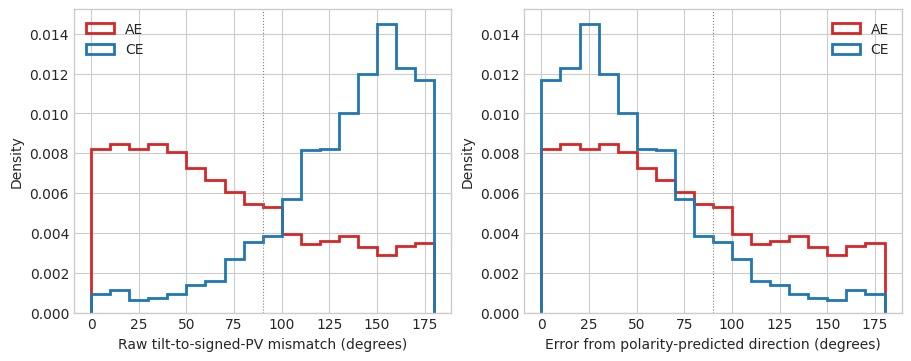

In [4]:
planetary['raw_signed_PV_mismatch'] = planetary.dtheta_PV_grad
planetary['preference_error'] = np.where(planetary.Cyc.eq('AE'),
    planetary.raw_signed_PV_mismatch, 180.0 - planetary.raw_signed_PV_mismatch)
planetary['response_cosine'] = np.cos(np.deg2rad(planetary.raw_signed_PV_mismatch))
display(planetary.groupby('Cyc').agg(
 observations=('Eddy','size'), eddies=('Eddy','nunique'),
 median_raw_mismatch=('raw_signed_PV_mismatch','median'),
 median_preference_error=('preference_error','median'),
 mean_response_cosine=('response_cosine','mean')).round(3))
fig,axs=plt.subplots(1,2,figsize=(9,3.5),constrained_layout=True)
for cyc,color in [('AE','tab:red'),('CE','tab:blue')]:
 part=planetary[planetary.Cyc==cyc]
 axs[0].hist(part.raw_signed_PV_mismatch,bins=np.arange(0,181,10),density=True,histtype='step',lw=2,color=color,label=cyc)
 axs[1].hist(part.preference_error,bins=np.arange(0,181,10),density=True,histtype='step',lw=2,color=color,label=cyc)
axs[0].set(xlabel='Raw tilt-to-signed-PV mismatch (degrees)',ylabel='Density')
axs[1].set(xlabel='Error from polarity-predicted direction (degrees)',ylabel='Density')
for ax in axs: ax.axvline(90,color='0.5',ls=':',lw=.8);ax.legend(frameon=False)


## 3. Eddy-level vector components

First average each component within each eddy. These eddy means, rather than individual days, form the principal sampling units. Positive x is eastward and positive y is northward.

,eddy_days,mean_x_km,median_x_km,mean_y_km,median_y_km
Cyc,,,,,
AE,5184,1.40,2.51,6.76,6.02
CE,1069,5.07,5.16,-12.65,-9.72


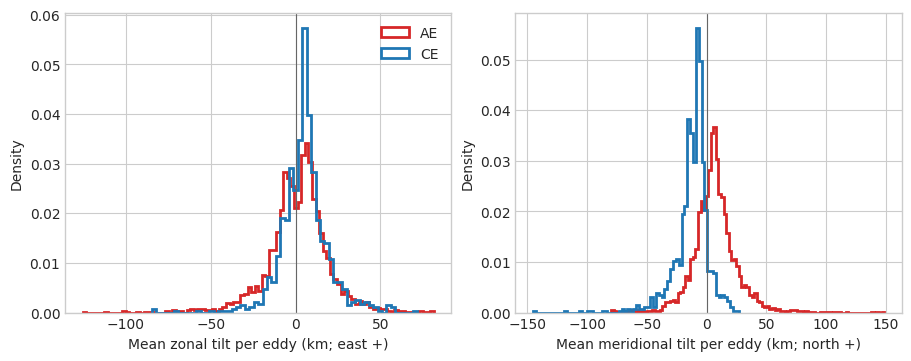

In [5]:
display(planetary.groupby('Cyc').agg(
    eddy_days=('Day', 'size'),
    mean_x_km=('tilt_x_km', 'mean'), median_x_km=('tilt_x_km', 'median'),
    mean_y_km=('tilt_y_km', 'mean'), median_y_km=('tilt_y_km', 'median')
).round(2))

fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    part = planetary[planetary.Cyc == cyc]
    axs[0].hist(part.tilt_x_km, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
    axs[1].hist(part.tilt_y_km, bins='fd', density=True, histtype='step', lw=2, color=color, label=cyc)
for ax, label in zip(axs, ['Mean zonal tilt per eddy (km; east +)', 'Mean meridional tilt per eddy (km; north +)']):
    ax.axvline(0, color='0.4', lw=.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
axs[0].legend(frameon=False);

## 4. Eddy-bootstrap uncertainty and explicit hypothesis contrasts

The shared-zonal hypothesis predicts `AE_x - CE_x ≈ 0`. The opposite-meridional hypothesis predicts `AE_y + CE_y ≈ 0`, alongside AE and CE meridional means having opposite signs. Bootstrap intervals are resampled over eddies.

In [6]:
rng = np.random.default_rng(42)
N_BOOT = 10_000
ae = eddy_vectors[eddy_vectors.Cyc == 'AE']
ce = eddy_vectors[eddy_vectors.Cyc == 'CE']
boot = np.empty((N_BOOT, 4))
for i in range(N_BOOT):
    a = ae.sample(len(ae), replace=True, random_state=rng.integers(2**32 - 1))
    c = ce.sample(len(ce), replace=True, random_state=rng.integers(2**32 - 1))
    boot[i] = [a.x_km.mean(), c.x_km.mean(), a.y_km.mean(), c.y_km.mean()]

contrasts = pd.DataFrame({
    'quantity': ['AE mean x', 'CE mean x', 'AE x − CE x', 'AE mean y', 'CE mean y', 'AE y + CE y'],
    'estimate_km': [ae.x_km.mean(), ce.x_km.mean(), ae.x_km.mean()-ce.x_km.mean(),
                    ae.y_km.mean(), ce.y_km.mean(), ae.y_km.mean()+ce.y_km.mean()],
    'low_95_km': np.percentile(np.c_[boot[:,0], boot[:,1], boot[:,0]-boot[:,1],
                                      boot[:,2], boot[:,3], boot[:,2]+boot[:,3]], 2.5, axis=0),
    'high_95_km': np.percentile(np.c_[boot[:,0], boot[:,1], boot[:,0]-boot[:,1],
                                       boot[:,2], boot[:,3], boot[:,2]+boot[:,3]], 97.5, axis=0),
})
display(contrasts.round(2))

NameError: name 'eddy_vectors' is not defined

## 5. Sensitivity checks

Repeat the component estimates for dominance factors 2, 3 and 4 and minimum depths of 2,000, 3,000 and 4,000 m. A robust background direction should not depend on one arbitrary cutoff.

In [ ]:
rows = []
for factor in [2.0, 3.0, 4.0]:
    for depth in [2000.0, 3000.0, 4000.0]:
        cfg = PVAlignmentConfig(dominance_factor=factor, min_open_ocean_depth_m=depth, min_tilt_distance_km=MIN_TILT_km)
        use = add_pv_alignment_diagnostics(df, cfg)
        use = use[use.open_ocean_planetary & use.direction_valid].copy()
        use['x'] = use.TiltDis * np.sin(np.deg2rad(use.TiltDir))
        use['y'] = use.TiltDis * np.cos(np.deg2rad(use.TiltDir))
        means = use.groupby('Cyc')[['x', 'y']].mean()
        for cyc in means.index:
            rows.append({'dominance_factor': factor, 'min_depth_m': depth, 'Cyc': cyc,
                         'mean_x_km': means.loc[cyc, 'x'], 'mean_y_km': means.loc[cyc, 'y'],
                         'eddies': use.loc[use.Cyc == cyc, 'Eddy'].nunique()})
display(pd.DataFrame(rows).round(2))

## 6. Does stronger PV gradient help alignemnt

It seems that a strogner beta effect doesnt help align the tilt (i.e. doesn tmake AEs titl more north, or CEs more south).\
This tells me that the zonal component causing the eddies to til eastward is potentially postively proportional to beta.

In [ ]:
ALIGNMENT_DEG = 45
RANDOM_TOLERANCE_FRACTION = ALIGNMENT_DEG / 180.0
planetary['log_PV_grad_mag'] = np.log(planetary.PV_grad_mag)
planetary['raw_signed_PV_mismatch'] = planetary.dtheta_PV_grad
planetary['preference_error'] = np.where(planetary.Cyc.eq('AE'),
    planetary.raw_signed_PV_mismatch, 180.0-planetary.raw_signed_PV_mismatch)
planetary['within_tolerance'] = planetary.preference_error <= ALIGNMENT_DEG

def binned_alignment(part, n_bins=20):
    part = part.copy()
    part['PV_bin'] = pd.qcut(part.log_PV_grad_mag, n_bins, duplicates='drop')
    return (part.groupby('PV_bin', observed=True)
            .agg(logPV=('log_PV_grad_mag', 'median'), angle=('preference_error','median'),
                 q25=('preference_error', lambda x: x.quantile(.25)),
                 q75=('preference_error', lambda x: x.quantile(.75)),
                 p_aligned=('within_tolerance','mean'), n=('Eddy', 'size'), eddies=('Eddy', 'nunique'))
            .reset_index(drop=True))

fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for cyc, color in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
    stats = binned_alignment(planetary[planetary.Cyc == cyc])
    axs[0].plot(stats.logPV, stats.angle, '-o', color=color, label=cyc)
    axs[0].fill_between(stats.logPV, stats.q25, stats.q75, color=color, alpha=.15)
    axs[1].plot(stats.logPV, 100 * stats.p_aligned, '-o', color=color, label=cyc)
axs[0].axhline(90, color='0.5', ls=':', lw=.8)
axs[0].axhline(ALIGNMENT_DEG, color='0.5', ls='--', lw=.8)
axs[1].axhline(100 * RANDOM_TOLERANCE_FRACTION, color='0.5', ls=':', lw=.8)
axs[0].set(xlabel=r'$\log |\nabla \mathrm{PV}|$', ylabel='Median error from predicted direction (°)', ylim=(0, 180))
axs[1].set(xlabel=r'$\log |\nabla \mathrm{PV}|$', ylabel=rf'$P(\Delta\theta \leq {ALIGNMENT_DEG:.0f}^\circ)$ (%)', ylim=(0, 100))
for ax in axs: ax.legend(frameon=False)

#### Beta effect

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.6), sharey=True, constrained_layout=True)
df_ = planetary.copy()
df_['PV_grad_mag_log'] = np.log(df_.PV_grad_mag)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("PV_grad_mag_log", r"$log(|\nabla PV|)$", None, True),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()